# CE444: Geotechnical Design, Homework Assignment 5


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sympy as sy
from icecream import ic

## Problem 1

Solved on paper.

## Problem 2

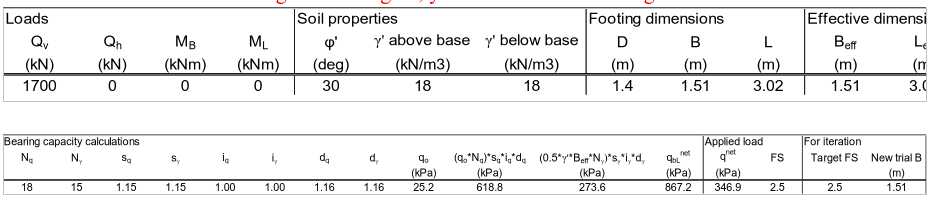

Correct answer: For friction angle of 45 degree, you should be calculating a foundation width of 0.47 m.

In [2]:
phis = np.linspace(30, 45, 16)
phiR = (np.pi/180) * phis
print(phis)
print(phiR)

[30. 31. 32. 33. 34. 35. 36. 37. 38. 39. 40. 41. 42. 43. 44. 45.]
[0.52359878 0.54105207 0.55850536 0.57595865 0.59341195 0.61086524
 0.62831853 0.64577182 0.66322512 0.68067841 0.6981317  0.71558499
 0.73303829 0.75049158 0.76794487 0.78539816]


In [29]:
# known values based on variables

saftey = 2.5
gamma_soil = 18 # kN/m^3
z_embed = 1.4 # m
q0 = gamma_soil * z_embed # kPa

i_q = 1
i_gamma = 1

s_q = (1 + (0.1/2) * ((1 + np.sin(np.radians(phis)))/ (1 - np.sin(np.radians(phis)))))
s_gamma = s_q

N_q = ((1 + np.sin(np.radians(phis)) )/ (1 - np.sin(np.radians(phis))) ) * np.exp(np.pi * np.tan(np.radians(phis)))

N_gamma = 1.5* (N_q - 1) * np.tan(np.radians(phis))

ic(saftey, gamma_soil, z_embed, q0, i_q, i_gamma, s_q, s_gamma, N_q, N_gamma)

ic| saftey: 2.5
    gamma_soil: 18
    z_embed: 1.4
    q0: 25.2
    i_q: 1
    i_gamma: 1
    s_q: array([1.15      , 1.15620175, 1.16272942, 1.169606  , 1.1768566 ,
                1.18450862, 1.192592  , 1.20113956, 1.21018729, 1.21977475,
                1.2299455 , 1.24074757, 1.25223406, 1.26446379, 1.27750202,
                1.29142136])
    s_gamma: array([1.15      , 1.15620175, 1.16272942, 1.169606  , 1.1768566 ,
                    1.18450862, 1.192592  , 1.20113956, 1.21018729, 1.21977475,
                    1.2299455 , 1.24074757, 1.25223406, 1.26446379, 1.27750202,
                    1.29142136])
    N_q: array([ 18.40112222,  20.63079316,  23.17677621,  26.0920121 ,
                 29.43979237,  33.29609149,  37.75249717,  42.91991165,
                 48.9332527 ,  55.95745874,  64.19520639,  73.89689143,
                 85.37362303,  99.01425896, 115.30790234, 134.87384063])
    N_gamma: array([ 15.0698139 ,  17.6930558 ,  20.78638166,  24.44241478,
              

(2.5,
 18,
 1.4,
 25.2,
 1,
 1,
 array([1.15      , 1.15620175, 1.16272942, 1.169606  , 1.1768566 ,
        1.18450862, 1.192592  , 1.20113956, 1.21018729, 1.21977475,
        1.2299455 , 1.24074757, 1.25223406, 1.26446379, 1.27750202,
        1.29142136]),
 array([1.15      , 1.15620175, 1.16272942, 1.169606  , 1.1768566 ,
        1.18450862, 1.192592  , 1.20113956, 1.21018729, 1.21977475,
        1.2299455 , 1.24074757, 1.25223406, 1.26446379, 1.27750202,
        1.29142136]),
 array([ 18.40112222,  20.63079316,  23.17677621,  26.0920121 ,
         29.43979237,  33.29609149,  37.75249717,  42.91991165,
         48.9332527 ,  55.95745874,  64.19520639,  73.89689143,
         85.37362303,  99.01425896, 115.30790234, 134.87384063]),
 array([ 15.0698139 ,  17.6930558 ,  20.78638166,  24.44241478,
         28.77432326,  33.92095008,  40.05337831,  47.38337881,
         56.17434205,  66.75550889,  79.54061156,  95.05245142,
        113.95552712, 137.09966271, 165.57878724, 200.81076094]))

In [34]:
# solvables 

B = sy.Symbol('B') 

widths = np.zeros(len(phis)) # initializing array

for i in range(len(widths)):
    depth_factor = (1 + (0.1*(z_embed/B)*sy.sqrt((1 + sy.sin(phiR[i]))/(1 - sy.sin(phiR[i])))))
    surcharge_term = q0 * float(N_q[i]) * float(s_q[i]) * i_q * depth_factor
    gamma_term = 0.5*gamma_soil*B*float(N_gamma[i])*float(s_gamma[i])*i_gamma * depth_factor
    q_bL_net_cap = ((1.7*10**3)/(2*B**2) - q0)*saftey
    widths[i] = sy.solve(surcharge_term + gamma_term - q_bL_net_cap)[0]

ic(widths)

ic| widths: array([1.49282384, 1.4063886 , 1.32279494, 1.24199245, 1.1639301 ,
                   1.08855724, 1.01582445, 0.94568435, 0.8780923 , 0.81300712,
                   0.75039183, 0.69021433, 0.63244828, 0.57707393, 0.52407919,
                   0.47346073])


array([1.49282384, 1.4063886 , 1.32279494, 1.24199245, 1.1639301 ,
       1.08855724, 1.01582445, 0.94568435, 0.8780923 , 0.81300712,
       0.75039183, 0.69021433, 0.63244828, 0.57707393, 0.52407919,
       0.47346073])

In [35]:
# back calc to check FS = 2.5
q_bL_net_backcalc = np.zeros(len(phis))
q_bL_net_demand = np.zeros(len(phis))

depth_factor = (1 + (0.1*(z_embed/widths)*np.sqrt((1 + np.sin(phiR))/(1 - np.sin(phiR)))))
# ic(depth_factor) # something is BARELY off...
surcharge_term = q0 * N_q * s_q * i_q * depth_factor
gamma_term = 0.5*18*widths*N_gamma*s_gamma*i_gamma * depth_factor
q_bL_net_backcalc = surcharge_term + gamma_term - q0
q_bL_net_demand = (1.7*10**3)/(2*widths**2)

ic(q_bL_net_backcalc)
ic(q_bL_net_demand)

FS = q_bL_net_backcalc/q_bL_net_demand

ic(FS)


ic| q_bL_net_backcalc: array([ 865.34635743,  986.15611182, 1126.23390958, 1289.39330797,
                              1480.3744442 , 1705.11422182, 1971.10943201, 2287.90994384,
                              2667.79611819, 3126.72047531, 3685.63355766, 4372.37644008,
                              5224.42184538, 6292.9069444 , 7648.66655438, 9391.42177473])
ic| q_bL_net_demand: array([ 381.41854297,  429.74244473,  485.77356383,  551.03732319,
                             627.42977768,  717.32568873,  823.7237728 ,  950.44397754,
                            1102.39844727, 1285.96819013, 1509.53342306, 1784.23057603,
                            2125.04873815, 2552.44277776, 3094.74662175, 3791.84870989])
ic| FS: array([2.26875797, 2.29476079, 2.31843392, 2.33993825, 2.3594265 ,
               2.3770433 , 2.39292527, 2.40720126, 2.41999263, 2.43141354,
               2.44157135, 2.45056693, 2.45849507, 2.46544487, 2.47150009,
               2.47673958])


array([2.26875797, 2.29476079, 2.31843392, 2.33993825, 2.3594265 ,
       2.3770433 , 2.39292527, 2.40720126, 2.41999263, 2.43141354,
       2.44157135, 2.45056693, 2.45849507, 2.46544487, 2.47150009,
       2.47673958])

Text(0, 0.5, 'Width (m)')

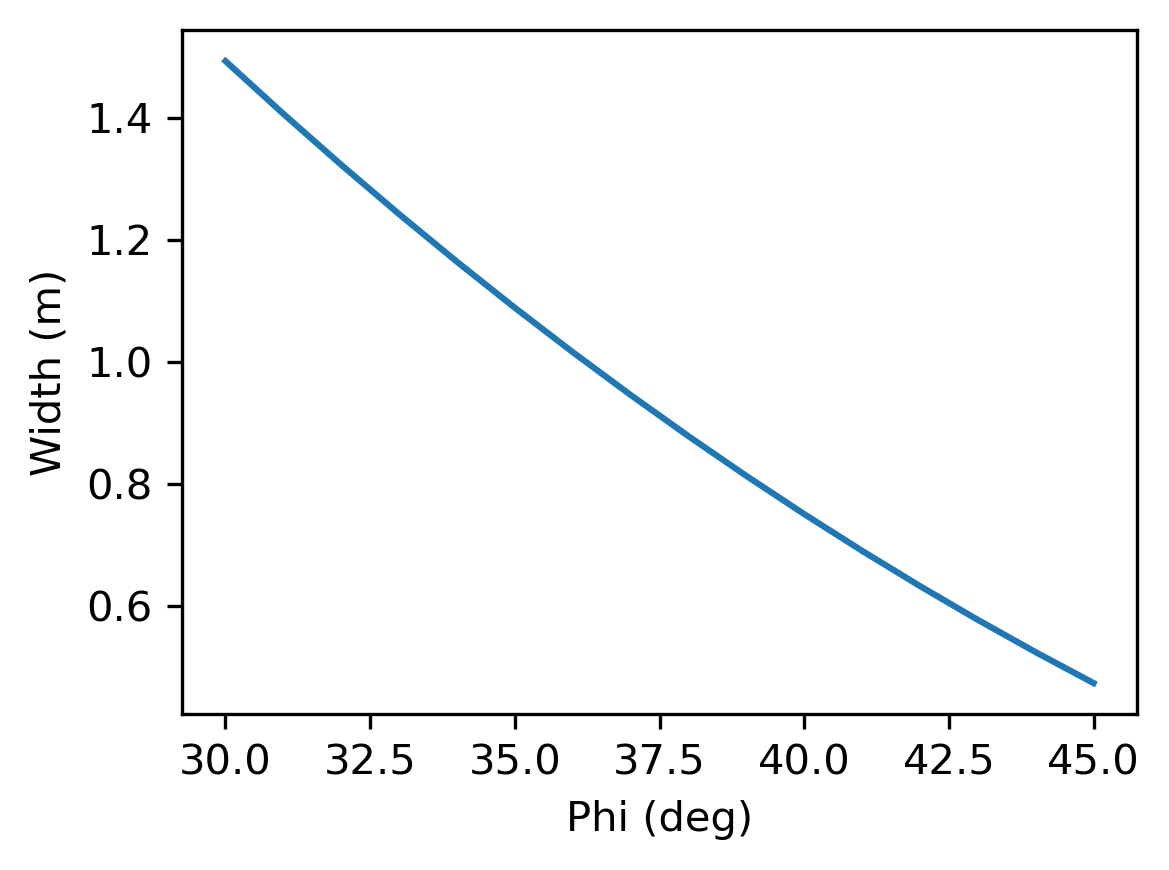

In [36]:
fig, ax = plt.subplots(figsize=(4,3), tight_layout = True, dpi = 300)

ax.plot(phis, widths)
ax.set_xlabel('Phi (deg)')
ax.set_ylabel('Width (m)')

## Problem 3

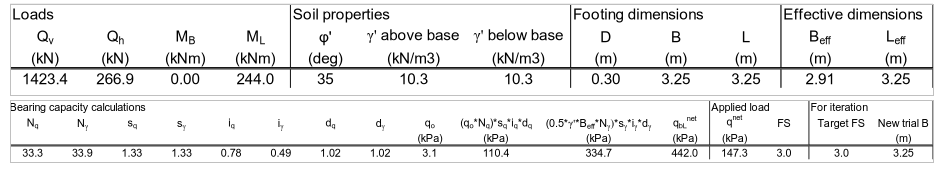